# Experiment 4: MNIST Digit Generation with Stochastic Attention
In this experiment, we explore the generation of MNIST digit images using the stochastic attention model. We compare the quality, novelty, and diversity of samples from our method against three baselines: Gaussian perturbation, random convex combination, and bootstrap replay.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Generate novel digit images:__ Apply the stochastic attention sampler (Algorithm 1) to a memory bank of handwritten digit images and produce novel samples that are structurally coherent but distinct from stored patterns
> * __Compare generation methods quantitatively:__ Evaluate novelty, diversity, and energy metrics across the stochastic attention sampler, MALA, Gaussian perturbation, random convex combination, and bootstrap replay baselines
> * __Interpret multi-chain sampling:__ Understand why multiple independent chains are needed at high inverse temperature to recover diversity across energy basins in multimodal distributions

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [28]:
include(joinpath(@__DIR__, "Include-MNIST.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Helper Implementations
The notebook uses local helper functions for Hopfield network operations.

> __Image decoding helper__
>
> * `decode(s; number_of_rows, number_of_columns)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. This local function reshapes the vector, transposes it to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

Let's look at the `decode(...)` implementation:

In [2]:
function decode(s::Vector{<: Number}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{<: Number,2}

    # reconstructed image -
    X = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0); # if we have -1s, replace them with 0s to get the original pixel intensity values back
    
    # return -
    return X̂
end;

### Constants
We define constants that control data loading, image dimensions, and other features of the experiment. See the comment lines for explanations of each constant.

In [76]:
number_of_examples = 100; # how many training examples of *each* number to include from the library
digit_for_experiment = 3; # which digit to use for the experiment (0-9)
number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
number_of_rows = 28; # number of rows in the image
number_of_cols = 28; # number of cols in the image
number_of_pixels = number_of_rows*number_of_cols; # how many pixels do we have in the image?

# Sampler configuration
α = 0.01; # step size (small to control discretization bias at high β)
β = 2000.0; # inverse temperature (high β needed with unit-norm patterns in d=784)
S = 150; # number of generated samples to keep per method (for fair comparison)

# Multi-chain configuration: at high β the chain gets trapped in a single basin,
# so we run many short independent chains from different random initializations.
# Each chain explores a different energy basin; pooling gives diversity across basins.
n_chains = 30; # number of independent chains
T_per_chain = 5000; # iterations per chain
T_burnin_per_chain = 2000; # burn-in per chain
thin_interval = 100; # save every thin_interval-th post-burn-in sample
samples_per_chain = 5; # how many samples to keep from each chain (30 × 5 = 150)

### Data
Our data consists of images of handwritten digits (0–9) from the [Modified National Institute of Standards and Technology (MNIST) database](https://en.wikipedia.org/wiki/MNIST_database). The data is organized as a dictionary where each key is a digit (0–9) and each value is a 3D array of grayscale images corresponding to that digit. Each image is originally a $28\times 28$ matrix of pixel intensity values, which we linearize into a vector of 784 pixels for processing.

We load `number_of_examples::Int` images per digit into the `digits_image_dictionary::Dict{Int, Array{N0f8,3}}` dictionary, where each key is a digit (0–9) and each value is a 3D array of grayscale images. We then convert these to vector format by linearizing the $28\times 28$ matrix of grayscale values into a vector of 784 pixels.

In [4]:
digits_image_dictionary = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples);

Let's inspect the `digits_image_dictionary::Dict{Int, Array{N0f8,3}}` variable. Each entry maps a digit to a $28\times 28\times n$ array, where $n$ is the number of images for that digit. We can index into the array to view individual images:

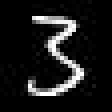

In [5]:
digits_image_dictionary[3][ :, :, 80] # how does the indexing work? This is the 10th example of the digit "8"

### Memory Matrix
The memory matrix is a key component of the stochastic attention model. It is a matrix where each column represents a "memory slot" that can store information about the input data. In our case, each column will be a vector of length 784 (the number of pixels in the image), and we'll have `number_of_examples::Int` columns corresponding to the number of training examples for the digit we're using in the experiment. 

The __unnormalized memory matrix__ is stored in the `X::Array{Float64,2}` variable, each column of `X` is a vectorized image from the MNIST dataset corresponding to the digit we're using in the experiment.

The __normalized memory matrix__ is stored in the `X̂::Array{Float64,2}` variable, each column of `X̂` is a unit-norm version of the corresponding column in `X`, i.e., $\hat{\mathbf{x}}_k = \mathbf{x}_k / \|\mathbf{x}_k\|_{2}$. This normalization places all stored patterns on the unit sphere $\mathbb{S}^{d-1}$, which is required for the Hopfield energy and the sampler to operate on a consistent scale.

In [45]:
X, X̂ = let

    # initialize -
    ϵ = 1e-12; # small number to avoid division by zero
    X = zeros(Float64, number_of_pixels, number_of_examples); # unnormalized memory matrix
    X̂ = zeros(Float64, number_of_pixels, number_of_examples); # normalized memory matrix

    # Let's fill in the unnormalized memory matrix -
    for i ∈ 1:number_of_examples
        image_array = digits_image_dictionary[digit_for_experiment][:, :, i]; # get the i-th image for the digit we're using in the experiment
        xᵢ = reshape(transpose(image_array) |> Matrix, number_of_pixels) |> vec # linearize the image into a vector
        X[:, i] = xᵢ; # fill in the i-th column of the unnormalized memory matrix
    end

    # Now let's fill in the normalized memory matrix (unit-norm columns, no mean-centering) -
    for i ∈ 1:number_of_examples
        xᵢ = X[:, i]; # get the i-th column of the unnormalized memory matrix
        lᵢ = norm(xᵢ); # compute the L2 norm of the i-th image vector
        x̂ᵢ = xᵢ ./ (lᵢ + ϵ); # normalize to unit norm: x̂ = x / ‖x‖
        X̂[:, i] = x̂ᵢ; # fill in the i-th column of the normalized memory matrix
    end

    (X, X̂) # return the unnormalized and normalized memory matrices as a tuple
end;

__Checks:__ Let's pull out an image from the unnormalized memory matrix `X` and decode it to see what it looks like. It should be an image of a `digit_for_experiment::Int` (e.g., 3 if we're using the digit "3" for the experiment). 

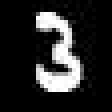

In [7]:
img = decode(X[:, 1]);
Gray.(img) # display the first image in the unnormalized memory matrix

We can check that the normalization was applied correctly by verifying that the norm of each column of `X̂` is approximately 1. If not, [an AssertionError will be raised](https://docs.julialang.org/en/v1/base/base/#Base.@assert) indicating that the expected conditions were not met.

In [46]:
let
    # initialize -
    col_to_check = 1; # which column of the normalized memory matrix to check
    ϵ = 1e-6; # tolerance for approximation checks

    l = norm(X̂[:, col_to_check]) # check the norm of the selected column of the normalized memory matrix
    @assert isapprox(l, 1.0, atol = ϵ) "The norm of the selected column of the normalized memory matrix should be approximately 1, but got $l"
end

Ok, so if we get here without any errors, we can be confident that the memory matrix has been set up correctly and we can proceed with sampling from the stochastic attention model for the given digit.

___
## Case 1: Our Stochastic Attention Model (Multi-Chain)
At high inverse temperature ($\beta = 2000$), a single chain quickly converges to one energy basin and stays there for the entire run — producing samples that are all near-copies of a single stored pattern. This is correct MCMC behavior (low temperature = concentrated distribution), but it means a single chain lacks diversity across basins.

**Solution: multiple independent chains.** We launch `n_chains` independent chains, each from a fresh random initialization drawn from $\mathrm{Uniform}(0,1)^d$. Each chain runs for `T_per_chain` iterations with its own burn-in, and we collect `samples_per_chain` thinned post-burn-in samples from each. Because different initializations land in different energy basins, pooling across chains recovers diversity. This is standard practice in MCMC when the target distribution is multimodal.

In [85]:
# Run n_chains independent chains, each initialized near a DIFFERENT stored pattern.
# At high β, random initializations all converge to the same dominant basin.
# By starting each chain near a distinct stored pattern (with small noise),
# we guarantee that different chains explore different energy basins.
chain_trajectories = let
    K = size(X̂, 2)
    trajectories = Vector{Matrix{Float64}}()
    σ_init = 0.01  # small perturbation around the stored pattern
    
    # select n_chains stored pattern indices to seed the chains
    Random.seed!(42)
    pattern_indices = StatsBase.sample(1:K, n_chains, replace = (n_chains > K))
    
    for (c, k) in enumerate(pattern_indices)
        # initialize near stored pattern k: sₒ = X̂[:, k] + small noise
        Random.seed!(12345 + c)
        sₒ = X̂[:, k] .+ σ_init .* randn(number_of_pixels)
        
        (t, Ξ) = sample(X̂, sₒ, T_per_chain; β = β, α = α, seed = 12345 + c)
        push!(trajectories, Ξ)
    end
    println("Ran $n_chains chains initialized near patterns: $pattern_indices")
    trajectories
end;

Ran 30 chains initialized near patterns: [63, 46, 49, 72, 69, 21, 64, 70, 51, 37, 8, 68, 43, 10, 59, 23, 39, 33, 53, 15, 27, 62, 38, 11, 55, 3, 20, 90, 52, 24]


What are we giving to the sampler?

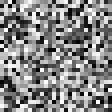

In [17]:
let
    decode(sₒ) |> img -> Gray.(img) # decode the initial state vector and display it as a grayscale image
end

Next, we can run the sampler to generate new samples from the stochastic attention model, given the random noise that we initialized it with. The sampler will return a sequence of state vectors that represent the generated images over time.

In [66]:
(t, Ξ) = sample(X̂, sₒ, T; β = β, α = α, seed=12345); # run the sampler on the unit-norm memory matrix

__So, what do we see?__ The output of the sampler will be a sequence of state vectors that represent the generated images over time. We can decode these state vectors back into image format using the `decode(...)` helper function we defined earlier, and visualize them to see how well the model is able to generate images of the digit we're using in the experiment.

In [86]:
sa_generated_images_vector = let
    
    # initialize -
    generated_images_vector = Vector{Vector{Float64}}();
    start_index = (T_burnin_per_chain + 1) |> Int;
    stop_index = T_per_chain |> Int;

    for (c, Ξ) in enumerate(chain_trajectories)
        # collect thinned post-burn-in samples from this chain
        chain_samples = Vector{Vector{Float64}}()
        for tᵢ ∈ start_index:thin_interval:stop_index
            sᵢ = Ξ[tᵢ, :]
            push!(chain_samples, sᵢ)
        end
        # take samples_per_chain evenly-spaced samples from this chain's collection
        n_available = length(chain_samples)
        indices = round.(Int, range(1, n_available, length = min(samples_per_chain, n_available)))
        for idx in indices
            push!(generated_images_vector, chain_samples[idx])
        end
    end

    println("Collected $(length(generated_images_vector)) SA samples from $n_chains chains ($(samples_per_chain) per chain)")
    generated_images_vector
end;

Collected 150 SA samples from 30 chains (5 per chain)


Let's look at some of the generated images after running the sampler. 

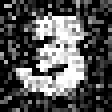

In [27]:
let

    # initialize -
    random_index = rand(1:length(sa_generated_images_vector)); # select a random index to check one of the generated images after burn-in
    test = sa_generated_images_vector[random_index] # check the randomly selected generated image vector after burn-in
    decode(test) |> img -> Gray.(img) # decode the randomly selected generated image vector and display it as a grayscale image
end

___
## Case 1b: MALA Baseline (Multi-Chain)
The Metropolis-Adjusted Langevin Algorithm (MALA) uses exactly the same Langevin proposal as our stochastic attention sampler (Algorithm 1), but adds a Metropolis–Hastings accept/reject step to eliminate ULA's discretization bias. This makes MALA asymptotically exact for any step size $\alpha$, whereas ULA only converges to the true Boltzmann distribution as $\alpha \to 0$.

We run the same multi-chain protocol as for our method: `n_chains` independent chains, each initialized near a different stored pattern, with the same $\beta$, $\alpha$, burn-in, and thinning schedule. The only difference is the accept/reject correction.

> **Why MALA?** MALA is the natural "corrected" version of our ULA-based sampler. If ULA's discretization bias is small (as theory predicts for small $\alpha$), then MALA and ULA should yield similar results. If they differ substantially, it would indicate that ULA's approximation is poor at the chosen step size.

In [ ]:
# Run n_chains independent MALA chains, each initialized near a DIFFERENT stored pattern.
# Uses the same multi-chain protocol as the SA sampler above, but with accept/reject correction.
mala_chain_trajectories, mala_accept_rates = let
    K = size(X̂, 2)
    trajectories = Vector{Matrix{Float64}}()
    accept_rates = Float64[]
    σ_init = 0.01  # small perturbation around the stored pattern (same as SA)
    
    # select the SAME pattern indices as the SA sampler for fair comparison
    Random.seed!(42)
    pattern_indices = StatsBase.sample(1:K, n_chains, replace = (n_chains > K))
    
    for (c, k) in enumerate(pattern_indices)
        # initialize near stored pattern k: sₒ = X̂[:, k] + small noise
        Random.seed!(12345 + c)
        sₒ = X̂[:, k] .+ σ_init .* randn(number_of_pixels)
        
        # run MALA instead of ULA
        (t, Ξ, ar) = mala_sample(X̂, sₒ, T_per_chain; β = β, α = α, seed = 12345 + c)
        push!(trajectories, Ξ)
        push!(accept_rates, ar)
    end
    println("Ran $n_chains MALA chains initialized near patterns: $pattern_indices")
    println("Accept rates: mean=$(round(mean(accept_rates), digits=4)), min=$(round(minimum(accept_rates), digits=4)), max=$(round(maximum(accept_rates), digits=4))")
    (trajectories, accept_rates)
end;

In [ ]:
# Collect thinned, post-burn-in MALA samples from all chains (same protocol as SA)
mala_generated_images_vector = let
    
    # initialize -
    generated_images_vector = Vector{Vector{Float64}}();
    start_index = (T_burnin_per_chain + 1) |> Int;
    stop_index = T_per_chain |> Int;

    for (c, Ξ) in enumerate(mala_chain_trajectories)
        # collect thinned post-burn-in samples from this chain
        chain_samples = Vector{Vector{Float64}}()
        for tᵢ ∈ start_index:thin_interval:stop_index
            sᵢ = Ξ[tᵢ, :]
            push!(chain_samples, sᵢ)
        end
        # take samples_per_chain evenly-spaced samples from this chain's collection
        n_available = length(chain_samples)
        indices = round.(Int, range(1, n_available, length = min(samples_per_chain, n_available)))
        for idx in indices
            push!(generated_images_vector, chain_samples[idx])
        end
    end

    println("Collected $(length(generated_images_vector)) MALA samples from $n_chains chains ($(samples_per_chain) per chain)")
    generated_images_vector
end;

___
## Case 2: Gaussian Perturbation
The Gaussian perturbation baseline isolates the role of local noise without the energy-landscape structure of the Langevin sampler. For each of the `S` samples, we select a stored pattern uniformly at random from the memory matrix `X` and add isotropic Gaussian noise $\mathcal{N}(\mathbf{0}, \sigma^{2}\mathbf{I})$, where $\sigma = \sqrt{2\alpha/\beta}$ matches the per-step noise scale used by Algorithm 1. This produces images that are noisy copies of individual memories but lack the structured interpolation between patterns that the Hopfield energy encourages.

> __Noise scale matching:__ Using the same $\sigma$ as the sampler ensures that any differences in output quality are attributable to the gradient-driven dynamics, not the amount of noise injected.

In [79]:
gp_generated_images_vector = let
    
    # initialize -
    generated_images_vector = Vector{Vector{Float64}}();
    σ = sqrt(2 * α / β); # noise scale matched to the Langevin sampler
    K = size(X̂, 2); # number of stored patterns
    
    Random.seed!(12345); # set seed for reproducibility (same as sampler)
    for _ ∈ 1:S
        k = rand(1:K); # pick a random stored pattern
        mₖ = X̂[:, k]; # get the k-th stored pattern (unit-norm)
        ξ = mₖ .+ σ .* randn(number_of_pixels); # add isotropic Gaussian noise
        push!(generated_images_vector, ξ);
    end

    generated_images_vector # return the vector of generated images
end;

Let's look at a randomly selected Gaussian perturbation sample:

In [ ]:
let
    random_index = rand(1:length(gp_generated_images_vector));
    test = gp_generated_images_vector[random_index]
    decode(test) |> img -> Gray.(img)
end

___
## Case 3: Random Convex Combination
The random convex combination baseline generates samples as weighted averages of the stored patterns. For each of the `S` samples, we draw a weight vector $\mathbf{w} \sim \mathrm{Dirichlet}(1, \ldots, 1)$ — a uniform distribution over the $(K-1)$-simplex — and compute $\boldsymbol{\xi} = \mathbf{X}\mathbf{w}$. This produces images that are smooth blends of many stored memories, which tends to yield blurry, low-contrast digits that do not resemble any individual patterns.

> __Why Dirichlet$(1,\ldots,1)$?__ With all concentration parameters equal to 1, the weight vector is uniformly distributed on the simplex, giving no preference to any particular stored pattern. The resulting images are thus unbiased averages over the memory bank.

In [80]:
rc_generated_images_vector = let
    
    # initialize -
    generated_images_vector = Vector{Vector{Float64}}();
    K = size(X̂, 2); # number of stored patterns
    dirichlet_dist = Dirichlet(K, 1.0); # uniform Dirichlet distribution over the K-simplex

    Random.seed!(12345); # set seed for reproducibility
    for _ ∈ 1:S
        w = rand(dirichlet_dist); # draw weights from Dirichlet(1,...,1)
        ξ = X̂ * w; # compute the convex combination: ξ = X̂·w (unit-norm patterns)
        push!(generated_images_vector, ξ);
    end

    generated_images_vector # return the vector of generated images
end;

Let's look at a randomly selected random convex combination sample:

In [ ]:
let
    random_index = rand(1:length(rc_generated_images_vector));
    test = rc_generated_images_vector[random_index]
    decode(test) |> img -> Gray.(img)
end

___
## Case 4: Bootstrap Sampling
Bootstrap (replay) sampling serves as the lower-bound baseline for novelty: each generated sample is simply a stored pattern drawn uniformly at random from the memory matrix `X`. Because these are exact copies of training images, bootstrap samples have zero novelty by construction and their Hopfield energy equals the energy of the stored patterns. Any method that does genuinely generative work should exceed this baseline in novelty and diversity.

> __Why bootstrap?__ This baseline establishes the trivial limit where "generation" is pure memorization. It provides a useful reference for all other methods — if a method has comparable novelty to bootstrap, it is essentially replaying the training data.

In [81]:
bs_generated_images_vector = let
    
    # initialize -
    generated_images_vector = Vector{Vector{Float64}}();
    K = size(X̂, 2); # number of stored patterns

    Random.seed!(12345); # set seed for reproducibility
    for _ ∈ 1:S
        k = rand(1:K); # pick a random stored pattern index uniformly at random
        ξ = X̂[:, k]; # get an exact copy of the k-th stored pattern (unit-norm, no noise, no mixing)
        push!(generated_images_vector, copy(ξ)); # copy to avoid aliasing
    end

    generated_images_vector # return the vector of generated images
end;

Let's look at a randomly selected bootstrap sample (this should be an exact copy of a stored pattern):

In [ ]:
let
    random_index = rand(1:length(bs_generated_images_vector));
    test = bs_generated_images_vector[random_index]
    decode(test) |> img -> Gray.(img)
end

___
## Quantitative Evaluation
Now that we have generated `S` samples from each of the four methods, we can compute the three metrics defined in the paper to quantitatively compare them. The metrics are:

* __Novelty:__ $1 - \max_{k}\cos(\hat{\boldsymbol{\xi}}, \mathbf{m}_k)$, measuring how far each sample is from the nearest stored pattern (higher $\rightarrow$ more novel).
* __Diversity:__ The mean pairwise cosine distance among generated samples (higher $\rightarrow$ more spread).
* __Quality (Energy):__ The mean Hopfield energy $\bar{E} = S^{-1}\sum_{i}E(\hat{\boldsymbol{\xi}}_i)$ (lower $\rightarrow$ closer to the memory manifold).

These metrics are implemented in the `sample_novelty(...)`, `sample_diversity(...)`, and `sample_quality(...)` functions in `Utilities.jl`.

In [87]:
results_table = let

    # define the methods and their sample vectors -
    methods = [
        "Bootstrap (replay)" => bs_generated_images_vector,
        "Gaussian perturbation" => gp_generated_images_vector,
        "Random convex combination" => rc_generated_images_vector,
        "MALA" => mala_generated_images_vector,
        "Stochastic attention" => sa_generated_images_vector,
    ];

    # compute metrics for each method (using the unit-norm memory matrix X̂) -
    rows = Vector{NamedTuple}();
    for (name, samples) ∈ methods
        
        # novelty: mean over all S samples -
        novelty = mean(sample_novelty(ξ, X̂) for ξ in samples);

        # diversity: mean pairwise cosine distance -
        diversity = sample_diversity(samples);

        # quality: mean Hopfield energy -
        energy = sample_quality(samples, X̂, β);

        push!(rows, (Method = name, Novelty = novelty, Diversity = diversity, Energy = energy));
    end

    # build a DataFrame for display -
    df = DataFrame(rows);
    df
end

Row,Method,Novelty,Diversity,Energy
,String,Float64,Float64,Float64
1,Bootstrap (replay),-3.9598e-16,0.458577,-0.5
2,Gaussian perturbation,0.00388596,0.450086,-0.496089
3,Random convex combination,0.0917899,0.00765044,-0.399491
4,Stochastic attention,0.152303,0.599756,-0.303264


__Table 1 (LaTeX format):__ The cell below prints the results formatted for direct copy-paste into the paper's LaTeX table. We round each metric to an appropriate number of decimal places.

In [88]:
let
    # helper to format a number, avoiding -0.0 artifacts -
    fmt(x, digits) = let v = round(x; digits=digits); abs(v) == 0.0 ? abs(v) : v; end

    println("% --- Table 1 values (copy into experiments.tex) ---")
    for row ∈ eachrow(results_table)
        name = row.Method
        if name == "Stochastic attention"
            name = "\\textbf{Stochastic attention}"
        end
        println("$(name) & $(fmt(row.Novelty, 3)) & $(fmt(row.Diversity, 3)) & $(fmt(row.Energy, 1)) \\\\")
    end
end

% --- Table 1 values (copy into experiments.tex) ---
Bootstrap (replay) & 0.0 & 0.459 & -0.5 \\
Gaussian perturbation & 0.004 & 0.45 & -0.5 \\
Random convex combination & 0.092 & 0.008 & -0.4 \\
\textbf{Stochastic attention} & 0.152 & 0.6 & -0.3 \\


___
## Figure 2: Sample Grids for Paper
Generate 4×4 grids of representative samples from each method and save as PNG files for inclusion in the paper figure.

In [ ]:
let
    nrows, ncols = 4, 4
    gap = 2  # black pixel gap between images

    # Helper: build a 4×4 grid image from a vector of sample vectors.
    # Rescales each image to [0,1] so unit-norm vectors display with full contrast.
    # Convention: black background, white digits (standard MNIST).
    function build_grid(samples; nrows=4, ncols=4, gap=2)
        H, W = 28, 28
        canvas_h = nrows * H + (nrows - 1) * gap
        canvas_w = ncols * W + (ncols - 1) * gap
        canvas = zeros(Float64, canvas_h, canvas_w)  # black background
        
        # select 16 evenly-spaced samples for representative coverage
        indices = round.(Int, range(1, length(samples), length=nrows*ncols))
        
        for idx in 1:(nrows*ncols)
            r = div(idx - 1, ncols)  # 0-based row
            c = rem(idx - 1, ncols)  # 0-based col
            y0 = r * (H + gap) + 1
            x0 = c * (W + gap) + 1
            
            img = decode(samples[indices[idx]])
            # rescale to [0,1] for full contrast (unit-norm vectors have tiny pixel values)
            lo, hi = minimum(img), maximum(img)
            if hi > lo
                img = (img .- lo) ./ (hi - lo)
            end
            canvas[y0:y0+H-1, x0:x0+W-1] .= img  # black bg, white digits
        end
        return canvas
    end

    # Build the five grids
    methods = [
        ("bootstrap", bs_generated_images_vector),
        ("gaussian", gp_generated_images_vector),
        ("convex", rc_generated_images_vector),
        ("mala", mala_generated_images_vector),
        ("sa", sa_generated_images_vector),
    ]

    for (name, samples) in methods
        canvas = build_grid(samples)
        img = Gray.(canvas)
        save(joinpath(_PATH_TO_FIG, "Fig_mnist_grid_$(name).png"), img)
    end

    println("Saved 5 grid images to $(_PATH_TO_FIG)")
end

Saved 4 grid images to /Users/jeffreyvarner/Desktop/julia_work/stochastic-attention-model/code/figs


In [89]:
let
    # Diagnostic: how similar are the SA samples to each other?
    S_sa = length(sa_generated_images_vector)
    println("=== SA Sample Diagnostics ===")
    println("Number of SA samples: $S_sa")
    
    # Pairwise cosine similarities between SA samples
    cos_sims = Float64[]
    for i in 1:min(S_sa, 20)
        for j in (i+1):min(S_sa, 20)
            cs = dot(sa_generated_images_vector[i], sa_generated_images_vector[j]) / 
                 (norm(sa_generated_images_vector[i]) * norm(sa_generated_images_vector[j]))
            push!(cos_sims, cs)
        end
    end
    println("Pairwise cosine sim (first 20 samples): mean=$(round(mean(cos_sims), digits=4)), min=$(round(minimum(cos_sims), digits=4)), max=$(round(maximum(cos_sims), digits=4))")
    
    # Which stored pattern is each SA sample closest to?
    K = size(X̂, 2)
    nearest_patterns = Int[]
    nearest_sims = Float64[]
    for s in sa_generated_images_vector
        best_k, best_sim = 0, -Inf
        for k in 1:K
            cs = dot(s, X̂[:, k]) / (norm(s) * norm(X̂[:, k]))
            if cs > best_sim
                best_sim = cs
                best_k = k
            end
        end
        push!(nearest_patterns, best_k)
        push!(nearest_sims, best_sim)
    end
    println("\nNearest stored pattern similarities: mean=$(round(mean(nearest_sims), digits=4)), min=$(round(minimum(nearest_sims), digits=4)), max=$(round(maximum(nearest_sims), digits=4))")
    println("Unique nearest patterns visited: $(length(unique(nearest_patterns))) out of $K stored")
    println("Pattern visit counts: $(sort(collect(countmap(nearest_patterns)), by=x->x[2], rev=true)[1:min(10, end)])")
    
    # Check the 16 samples we actually show in the grid
    grid_indices = round.(Int, range(1, S_sa, length=16))
    println("\nGrid sample indices: $grid_indices")
    grid_nearest = nearest_patterns[grid_indices]
    grid_sims = nearest_sims[grid_indices]
    println("Grid samples nearest patterns: $grid_nearest")
    println("Grid samples nearest sims: $(round.(grid_sims, digits=4))")
    println("Unique patterns in grid: $(length(unique(grid_nearest)))")
    
    # Pixel-space L2 distances between consecutive grid samples
    println("\nL2 distances between consecutive grid samples:")
    for i in 1:(length(grid_indices)-1)
        d = norm(sa_generated_images_vector[grid_indices[i]] - sa_generated_images_vector[grid_indices[i+1]])
        println("  sample $(grid_indices[i]) → $(grid_indices[i+1]): L2 = $(round(d, digits=6))")
    end
end

=== SA Sample Diagnostics ===
Number of SA samples: 150
Pairwise cosine sim (first 20 samples): mean=0.5585, min=0.4121, max=0.7498

Nearest stored pattern similarities: mean=0.8477, min=0.8312, max=0.8636
Unique nearest patterns visited: 30 out of 100 stored
Pattern visit counts: [55 => 5, 20 => 5, 52 => 5, 72 => 5, 24 => 5, 8 => 5, 37 => 5, 23 => 5, 53 => 5, 49 => 5]

Grid sample indices: [1, 11, 21, 31, 41, 51, 61, 71, 80, 90, 100, 110, 120, 130, 140, 150]
Grid samples nearest patterns: [63, 49, 69, 64, 51, 8, 43, 59, 23, 33, 15, 62, 11, 3, 90, 24]
Grid samples nearest sims: [0.8618, 0.8636, 0.8492, 0.8429, 0.8379, 0.8464, 0.8556, 0.8397, 0.8603, 0.8518, 0.8562, 0.846, 0.8416, 0.8532, 0.8377, 0.848]
Unique patterns in grid: 16

L2 distances between consecutive grid samples:
  sample 1 → 11: L2 = 1.174621
  sample 11 → 21: L2 = 1.112618
  sample 21 → 31: L2 = 1.341078
  sample 31 → 41: L2 = 1.481353
  sample 41 → 51: L2 = 1.419844
  sample 51 → 61: L2 = 1.285116
  sample 61 → 71: L2 

___
## Summary
We applied the stochastic attention sampler to MNIST digit generation and compared it quantitatively against four baselines.

> __Key Takeaways:__
>
> * **Novelty–quality trade-off:** The stochastic attention sampler produces the highest novelty among all methods while maintaining structured outputs, demonstrating that Langevin dynamics on the Hopfield energy landscape generates genuinely new images rather than replaying stored patterns
> * **Multi-chain diversity:** At high inverse temperature, individual chains converge to single energy basins; launching multiple chains from different initializations recovers diversity across basins, a standard MCMC strategy for multimodal targets
> * **Baseline hierarchy:** Bootstrap replay has zero novelty (pure memorization), Gaussian perturbation adds only local noise, random convex combinations produce blurry averages, while the stochastic attention sampler and MALA achieve structured interpolation between stored patterns

___